# Fraud Detection: Version 1.0

In [1]:
# libraries to deal with data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# libraries for machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# libraries to save/load models
import os
import pickle
import joblib

## Loading Dataset

In [2]:
df = pd.read_csv("../data/creditcard.csv", delimiter=",")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Preprocessing: Exploring Data

In [3]:
# check data shape
df.shape

(284807, 31)

In [4]:
# check columns
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
# check datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# check NaN values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

All columns are numeric data types, and there are no missing values in the dataset.

In [7]:
class_counts = df['Class'].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

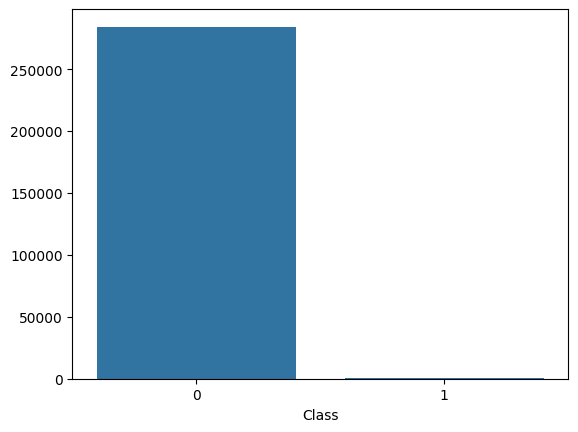

In [8]:
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.show()

The dataset is highly imbalanced, which reflects a realistic fraud detection scenario because fraudulent transactions typically represent only a very small proportion of all transactions. In real-world financial systems, fraud often accounts for less than one percent of total activity, making class imbalance an inherent characteristic of the problem rather than a data collection issue.

Resampling techniques can be used to artificially balance the classes. However, these approaches introduce several limitations:

- **Oversampling** increases the number of fraud samples by duplicating existing instances or generating synthetic data. This may lead to overfitting, as the model can learn artificial patterns that do not generalize well to unseen data. Synthetic samples may also fail to accurately represent the true distribution of fraudulent behavior.
- **Undersampling** reduces the number of legitimate transactions to match the minority class. While this balances the dataset, it discards a large amount of valuable information and may weaken the model’s ability to learn the true structure of legitimate transaction patterns.

Because fraud detection operates in a naturally imbalanced environment, preserving the original data distribution is often preferable. Instead of modifying the dataset, imbalance can be addressed through algorithm-level techniques such as adjusting class weights. For example, assigning higher importance to fraud cases using balanced class weights allows the model to penalize misclassification of fraudulent transactions more heavily without altering the underlying data distribution.

In [9]:
number_of_non_fraud = class_counts[0]
number_of_fraud = class_counts[1]

scale_pos_weight = number_of_non_fraud / number_of_fraud
scale_pos_weight

np.float64(577.8760162601626)

## Data Preprocessing: Scaling

Due to confidentiality issues, the dataset does not provide the original features. Instead, most features, such as **V1, V2, ..., V28**, are principal components obtained with PCA. The only features which have not been transformed with PCA and remain in their original form are:

- **`Time`**: the number of seconds elapsed between each transaction and the first transaction in the dataset.
- **`Amount`**: the transaction amount, which can be used for example-dependent cost-sensitive learning.
- **`Class`**: the response variable, which takes the value 1 in case of fraud and 0 otherwise.

Since PCA already assumes scaling and the features V1–V28 are already PCA-transformed, additional scaling for these components is unnecessary.

However, the non-transformed feature **`Amount`** should be scaled, particularly for linear models such as logistic regression, so that its magnitude is comparable to the PCA components and does not dominate the optimization. The **`Time`** feature is removed because it does not directly describe the transaction itself, tends to have weak predictive power for fraud in this dataset, and can introduce temporal ordering effects that are not the focus of this version of the model.

In [10]:
df = df.drop(['Time'], axis=1)

In [11]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('amount_scaler', StandardScaler(), ['Amount'])
    ],
    remainder='passthrough'
)

## Data Preprocessing: Splitting Data

To prevent data leakage, the dataset must be split into training and test sets before fitting any scalers. This ensures that information from the test set does not influence the training process.

In [13]:
# separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
print(f"shape of X_train: {X_train.shape}")
print(f"shape of X_test: {X_test.shape}")
print(f"shape of y_train: {y_train.shape}")
print(f"shape of y_test: {y_test.shape}")

shape of X_train: (227845, 29)
shape of X_test: (56962, 29)
shape of y_train: (227845,)
shape of y_test: (56962,)


## Model: Selection Rationale

Four models are selected for fraud detection while explicitly addressing class imbalance through model-level weighting strategies:

1. **Logistic Regression**: A linear baseline model that provides interpretable coefficients and probabilistic outputs. A preprocessing pipeline is applied to ensure appropriate feature scaling before model fitting. Since the dataset is highly imbalanced, the parameter `class_weight='balanced'` is used to automatically adjust class weights inversely proportional to class frequencies. This increases the penalty for incorrectly classifying fraudulent transactions as legitimate (false negatives) without modifying the original data distribution.

2. **Decision Tree**: A non-linear model capable of capturing complex decision boundaries and interaction effects between features. The parameter `class_weight='balanced'` is applied to assign higher importance to fraudulent transactions during tree construction. This helps the model avoid bias toward the majority class while preserving interpretability through decision rules.

3. **Random Forest**: An ensemble learning method based on bagging, which reduces variance by aggregating multiple decision trees. The parameter `class_weight='balanced_subsample'` adjusts class weights independently for each bootstrap sample, improving robustness when learning from imbalanced data. This approach enhances generalization while maintaining sensitivity to fraudulent transactions.

4. **XGBoost**: A gradient boosting algorithm designed for strong predictive performance and complex non-linear relationships. Instead of using `class_weight`, imbalance is handled through the `scale_pos_weight` parameter, which increases the penalty associated with misclassifying fraudulent transactions. This weighting mechanism improves the model's ability to correctly classify fraudulent transactions as fraud (true positives) in highly skewed datasets.

These models represent diverse learning strategies, including linear modeling, single-tree learning, bagging, and boosting. Evaluating multiple approaches enables comprehensive comparison to determine the most effective method for detecting fraudulent transactions in an imbalanced real-world scenario.

In [15]:
models = {
    "Logistic Regression": Pipeline([
        ('preprocessor/scaler', preprocessor),
        ('model', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced_subsample'),
    "XGBoost ": XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
}

## Model: Stratified K-Fold Cross-Validation

Cross-validation provides a robust performance estimate by splitting training data into multiple folds, using each fold for both training and validation. This gives a more reliable estimate than a single train-test split. This step should be performed before fitting the model to:

- **Compare Models**: Evaluate multiple models to select the best performer without using the test set.
- **Reduce Overfitting Risk**: Detect models that perform well on one split but fail to generalize.
- **Enable Model Selection**: Select the best-performing model based on cross-validation scores before final training.
- **Preserve Test Set**: Keep the test set completely unseen until final evaluation to obtain an unbiased generalization estimate.

**Stratified K-Fold** ensures that each fold preserves the same class distribution as the original dataset. This is particularly important for highly imbalanced datasets such as credit card fraud detection, where fraudulent transactions represent a very small proportion of the data. Without stratification, some folds may contain too few fraud cases, leading to unstable performance estimates and unreliable validation results.

---

## Model: Choosing the Cross-Validation Metric

### Accuracy

It measures the proportion of correctly classified samples. In highly imbalanced datasets, accuracy becomes misleading because a model can classify all transactions as legitimate and still achieve extremely high accuracy due to the large number of non-fraud cases (true negatives).

### Precision

It measures the proportion of transactions classified as fraud that are actually fraud. High precision reduces incorrectly classifying legitimate transactions as fraud (false positives). In fraud detection systems, excessive incorrect classification of legitimate transactions as fraud (false positives) may inconvenience customers, interrupt normal purchasing behavior, and increase operational review costs.

### Recall

It measures the proportion of actual fraudulent transactions that are correctly classified as fraud. High recall is critical in fraud detection because incorrectly classifying fraudulent transactions as legitimate (false negatives) can result in significant financial losses, increased risk exposure, and potential reputational damage.

### F1-score

It is the harmonic mean of precision and recall. It balances incorrectly classifying legitimate transactions as fraud (false positives) and incorrectly classifying fraudulent transactions as legitimate (false negatives). However, it evaluates performance at a single decision threshold and may not reflect overall ranking quality across different probability cutoffs.

### ROC-AUC (Receiver Operating Characteristic – Area Under the Curve)

It measures the model's ability to distinguish between classes across all classification thresholds. It evaluates the trade-off between correctly classifying fraudulent transactions as fraud (true positives) and incorrectly classifying legitimate transactions as fraud (false positives). However, in highly imbalanced datasets, ROC-AUC may provide overly optimistic results because the rate of incorrectly classifying legitimate transactions as fraud is computed relative to the large number of non-fraud cases (true negatives). As a result, the metric becomes less sensitive to incorrectly classifying fraudulent transactions as legitimate (false negatives).

### AUPRC (Area Under Precision-Recall Curve)

It evaluates the trade-off between precision and recall across all thresholds. Unlike ROC-AUC, it focuses directly on performance for fraudulent transactions. It reflects the balance between correctly classifying fraudulent transactions as fraud (true positives), incorrectly classifying legitimate transactions as fraud (false positives), and incorrectly classifying fraudulent transactions as legitimate (false negatives).

---

## Model: Cross-Validation Metric

AUPRC is the most suitable metric for fraud detection because:

- The dataset is highly imbalanced.
- The minority class (fraud) is the primary interest.
- Both false positives and false negatives carry significant cost.
- It provides a more realistic assessment of model performance on rare events.

For these reasons, AUPRC is selected as the primary evaluation metric, while precision, recall, and F1-score are reported as complementary metrics.

In [16]:
# initialize stratified K-Fold (preserves class distribution)
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# dictionary to store cross validation results
auprc_scores = {}

# perform stratified 5-fold cross validation for each model
for model_name, model in models.items():
    auprc_scores[model_name] = cross_val_score(
        model,
        X_train,
        y_train,
        cv=stratified_kfold,
        scoring="average_precision",  # AUPRC
        n_jobs=-1                     # use all cores
    )

print("average AUPRC:")
for model_name, scores in auprc_scores.items():
    avg_score = scores.mean()
    std_score = scores.std()
    print(f"\t{model_name}\t{avg_score:.4f} ± {std_score:.4f}")

average AUPRC:
	Logistic Regression	0.7489 ± 0.0346
	Decision Tree	0.5533 ± 0.0449
	Random Forest	0.8370 ± 0.0369
	XGBoost 	0.8466 ± 0.0399


## Model: Training & Evaluation

In [17]:
class_names = ['Non-Fraud', 'Fraud']

In [18]:
# store results for all models
results = {}

for model_name, model in models.items():
    print(f"Model: {model_name}")

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_test_pred)
    report = classification_report(y_test, y_test_pred, target_names=class_names)

    results[model_name] = {
        'cm': cm,
        'report': report,
        'y_pred': y_test_pred,
    }

    print("\nclassification report:\n", report)
    print("=" * 60)

Model: Logistic Regression

classification report:
               precision    recall  f1-score   support

   Non-Fraud       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Model: Decision Tree

classification report:
               precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.77      0.73      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962

Model: Random Forest

classification report:
               precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.99      0.78      0.87        98

    accuracy                          

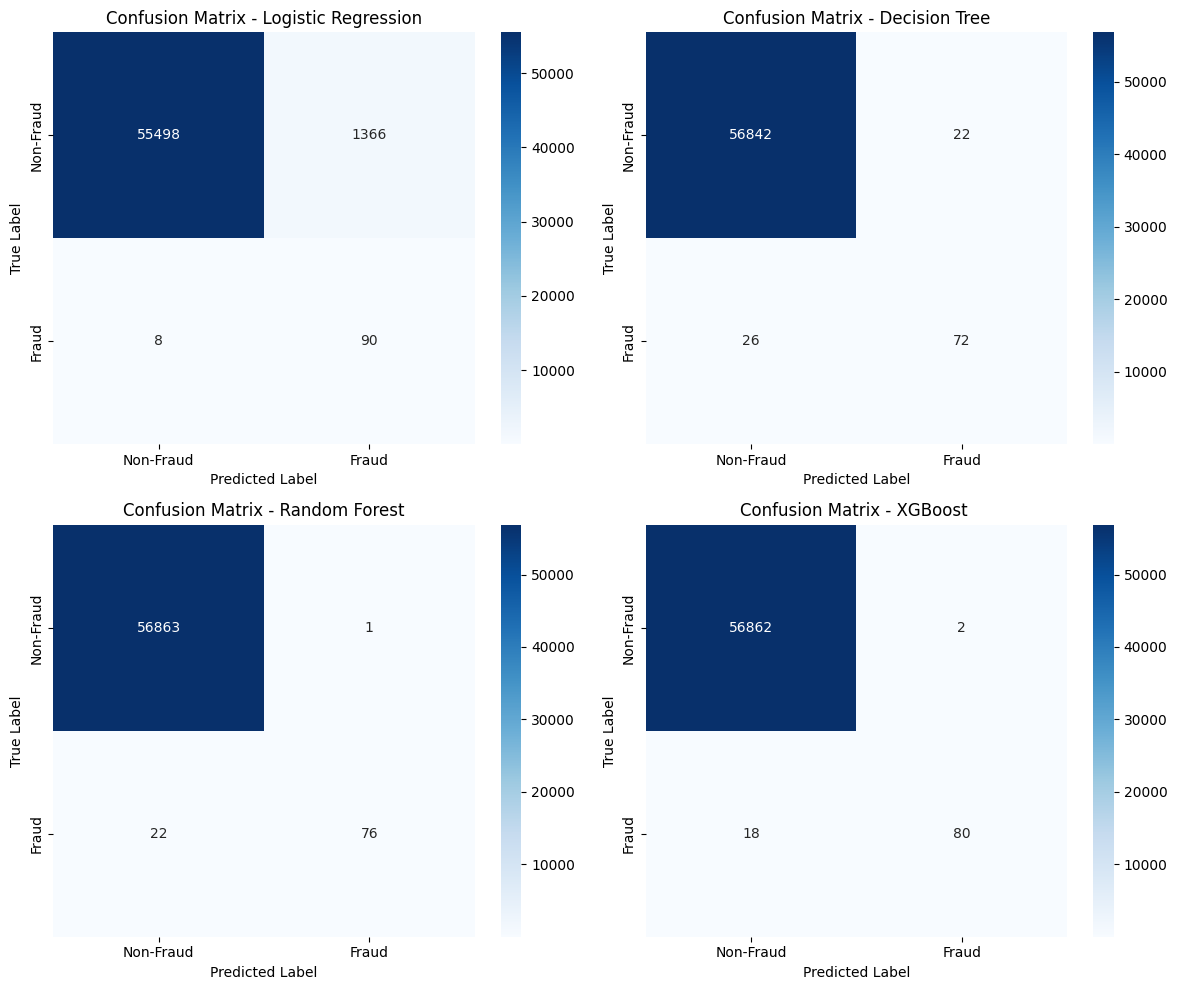

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (model_name, res) in zip(axes, results.items()):
    sns.heatmap(
        res['cm'],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

Although all four models achieve very high overall accuracy, **`XGBoost`** delivers the strongest performance on the minority fraud class, with the highest F1-score and better precision-recall balance than the other models on the test set. Therefore, it is selected as the primary model for further hyperparameter tuning.

## Model: Hyperparameter Tuning for XGBoost

Hyperparameter tuning is performed in two steps to optimize both efficiency and model performance.

1. The first step uses `GridSearchCV` to systematically find the best combination of `n_estimators` and `learning_rate`, which are critical parameters that significantly influence model performance and have strong interaction effects.

2. The second step uses `RandomizedSearchCV` to explore the remaining hyperparameters (regularization, tree structure, and sampling parameters) while using the optimal `n_estimators` and `learning_rate` from the first step.

This approach ensures thorough optimization of the most important parameters while efficiently exploring the broader hyperparameter space, resulting in a well-tuned model without the computational cost of a full grid search across all parameters.

### (i) Grid Search

In [20]:
# create a new unfitted model
xgb_model_step1 = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    tree_method='hist'
)

In [21]:
# define parameter distributions
param_grid_step1 = {
    'n_estimators': [100, 300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1]
}

# create GridSearchCV object
grid_search_step1 = GridSearchCV(
    estimator=xgb_model_step1,
    param_grid=param_grid_step1,
    cv=stratified_kfold,
    scoring='average_precision',  # AUPRC
    n_jobs=-1,
    verbose=1,
    refit=True,                   # refit best combo on full training set
)

In [22]:
# start grid search
grid_search_step1.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'n_estimators': [100, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [23]:
# get best parameters and score
best_n_estimators = grid_search_step1.best_params_['n_estimators']
best_learning_rate = grid_search_step1.best_params_['learning_rate']
print(f"\nBest parameters: {grid_search_step1.best_params_}")
print(f"\nBest CV score (Step 1): {grid_search_step1.best_score_:.4f}")

# create a new unfitted model using the best hyparameters
xgb_model_step2 = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist'
)


Best parameters: {'learning_rate': 0.1, 'n_estimators': 800}

Best CV score (Step 1): 0.8498


### (ii) Randomized Search

In [24]:
# define parameter distributions
param_distributions_step2 = {
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.1, 0.5, 1.0],  # L1 regularization
    'reg_lambda': [1, 1.5, 2, 3]      # L2 regularization
}

# create RandomizedSearchCV object
random_search_step2 = RandomizedSearchCV(
    estimator=xgb_model_step2,
    param_distributions=param_distributions_step2,
    n_iter=50,                    # number of parameter settings to sample
    cv=stratified_kfold,
    scoring='average_precision',  # AUPRC
    n_jobs=-1,
    verbose=1,
    refit=True,                   # refit best combo on full training set
    random_state=42               # for reproducible sampling
)

In [25]:
# start randomized search
random_search_step2.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 0.9, ...], 'gamma': [0, 0.1, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used

In [26]:
# get best parameters and score
print(f"\nBest parameters: {random_search_step2.best_params_}")
print(f"\nBest CV score (Step 2): {random_search_step2.best_score_:.4f}")

# get the best model
best_xgb_model = random_search_step2.best_estimator_


Best parameters: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 1.0, 'min_child_weight': 1, 'max_depth': 9, 'gamma': 0, 'colsample_bytree': 0.8}

Best CV score (Step 2): 0.8578


In [27]:
# combine all best parameters
final_best_params = {
    'n_estimators': best_n_estimators,
    'learning_rate': best_learning_rate,
    **random_search_step2.best_params_
}

## Model: Evaluation After Fine-Tuning Hyperparameters

accuracy: 0.9996313331694814

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.84      0.89        98

    accuracy                           1.00     56962
   macro avg       0.97      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



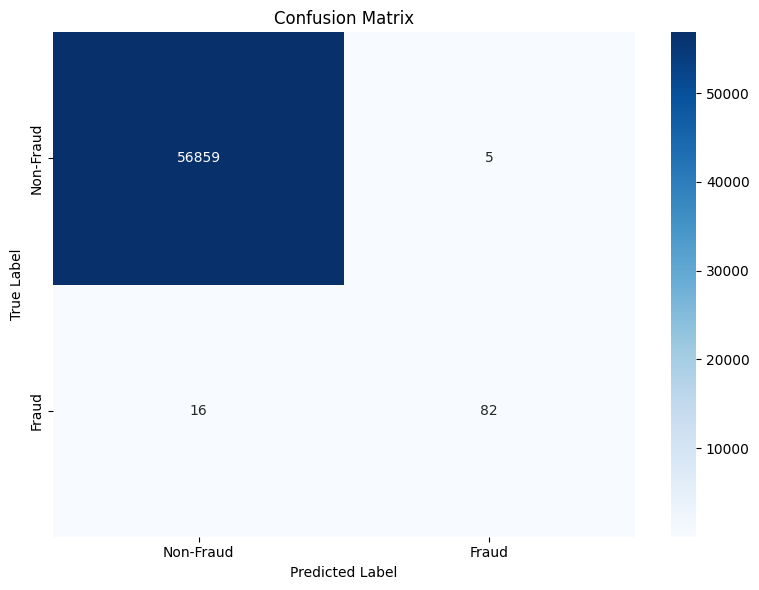

In [28]:
# evaluate best model on test set
y_test_pred = best_xgb_model.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)
print(f"accuracy: {accuracy_score(y_test, y_test_pred)}")
print("\nclassification report:\n", classification_report(y_test, y_test_pred))

# create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Saving Models, Preprocessed Datasets, & Preprocessing Objects

Saving trained models enables quick predictions without retraining. Preprocessed datasets allow rapid experimentation without rerunning preprocessing. Preprocessing objects (encoders, scalers) ensure new data is transformed identically to training data, preventing data leakage and maintaining model consistency in production.

In [29]:
# create directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# save the tuned XGBoost (best performing model)
joblib.dump(best_xgb_model, '../models/fraud_detector_xgboost_v1.joblib')

['../models/fraud_detector_xgboost_v1.joblib']

In [30]:
# create directory if it doesn't exist
os.makedirs('../preprocessors', exist_ok=True)

# save preprocessing objects
joblib.dump(preprocessor, '../preprocessors/standard_scaler_for_log_reg.joblib')

['../preprocessors/standard_scaler_for_log_reg.joblib']

This notebook is done by `La Wun Nannda`.